# Analytics London Crime Weather Data (2014 - 2016)

## 1. Importing packages
Add needed libraries for Analytics


In [60]:
# List of Require Libraries
required_packages <- c(
  "tidyverse", "lubridate", "broom", "scales",
  "corrplot", "rsample", "yardstick", "GGally", "knitr"
)

# Install
installed <- rownames(installed.packages())

# Check if Library is installed
for (pkg in required_packages) {
  if (!pkg %in% installed) install.packages(pkg)
}

# Run Librarys
library(tidyverse)
library(lubridate)
library(broom)
library(scales)
library(knitr)
library(corrplot)

## 2. Load Data
Load Final Merge CSV File from Github.

In [61]:
# Read CSV File From Github
raw_data <- read_csv(
  "https://raw.githubusercontent.com/bcroman/21006366_DA_Assessment/refs/heads/main/views/Crime_Weather_2014_2016.csv",
  show_col_types = FALSE
)

## 3. Initial Checks
Used to confirm that the dataset has loaded correctly,
that the expected variables are present, and that the time coverage and crime categories appear reasonable.

In [62]:
# Initial checks
cat("Rows:", nrow(raw_data), "\n")
cat("Columns:", ncol(raw_data), "\n")

# Display Data
summary(raw_data)
glimpse(raw_data)

Rows: 252 
Columns: 17 


      year          month       crime_month        major_category    
 Min.   :2014   Min.   : 1.00   Length:252         Length:252        
 1st Qu.:2014   1st Qu.: 3.75   Class :character   Class :character  
 Median :2015   Median : 6.50   Mode  :character   Mode  :character  
 Mean   :2015   Mean   : 6.50                                        
 3rd Qu.:2016   3rd Qu.: 9.25                                        
 Max.   :2016   Max.   :12.00                                        
  total_crimes      avg_temp        avg_dewp        avg_slp     
 Min.   :  925   Min.   :40.81   Min.   :35.19   Min.   : 9690  
 1st Qu.: 1889   1st Qu.:45.21   1st Qu.:39.36   1st Qu.:10000  
 Median : 5187   Median :52.89   Median :46.56   Median :10000  
 Mean   : 8444   Mean   :53.50   Mean   :45.49   Mean   : 9983  
 3rd Qu.:16409   3rd Qu.:61.65   3rd Qu.:51.52   3rd Qu.:10000  
 Max.   :26303   Max.   :67.73   Max.   :55.60   Max.   :10000  
   avg_visib          avg_wdsp        avg_mxpsd        

Rows: 252
Columns: 17
$ year           <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2…
$ month          <dbl> 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3…
$ crime_month    <chr> "01/01/2014", "01/01/2014", "01/01/2014", "01/01/2014",…
$ major_category <chr> "Robbery", "Violence Against the Person", "Criminal Dam…
$ total_crimes   <dbl> 2165, 12741, 4464, 4020, 930, 23285, 7910, 1878, 6767, …
$ avg_temp       <dbl> 44.59355, 44.59355, 44.59355, 44.59355, 44.59355, 44.59…
$ avg_dewp       <dbl> 40.44839, 40.44839, 40.44839, 40.44839, 40.44839, 40.44…
$ avg_slp        <dbl> 9999.9, 9999.9, 9999.9, 9999.9, 9999.9, 9999.9, 9999.9,…
$ avg_visib      <dbl> 5.974194, 5.974194, 5.974194, 5.974194, 5.974194, 5.974…
$ avg_wdsp       <dbl> 9.367742, 9.367742, 9.367742, 9.367742, 9.367742, 9.367…
$ avg_mxpsd      <dbl> 16.23226, 16.23226, 16.23226, 16.23226, 16.23226, 16.23…
$ avg_gust       <dbl> 466.0968, 466.0968, 466.0968, 466.0968, 466.0968, 466.0…
$ avg_max_temp   <

In [63]:
# Loop Through Year and Month
raw_data %>% count(year, month) %>% arrange(year, month) %>% print(n = 40)

# Loop Throiugh Crime Category
raw_data %>% count(major_category, sort = TRUE) %>% print()

# A tibble: 36 × 3
    year month     n
   <dbl> <dbl> <int>
 1  2014     1     7
 2  2014     2     7
 3  2014     3     7
 4  2014     4     7
 5  2014     5     7
 6  2014     6     7
 7  2014     7     7
 8  2014     8     7
 9  2014     9     7
10  2014    10     7
11  2014    11     7
12  2014    12     7
13  2015     1     7
14  2015     2     7
15  2015     3     7
16  2015     4     7
17  2015     5     7
18  2015     6     7
19  2015     7     7
20  2015     8     7
21  2015     9     7
22  2015    10     7
23  2015    11     7
24  2015    12     7
25  2016     1     7
26  2016     2     7
27  2016     3     7
28  2016     4     7
29  2016     5     7
30  2016     6     7
31  2016     7     7
32  2016     8     7
33  2016     9     7
34  2016    10     7
35  2016    11     7
36  2016    12     7
# A tibble: 7 × 2
  major_category                  n
  <chr>                       <int>
1 Burglary                       36
2 Criminal Damage                36
3 Drugs              

## 4. Cleaning Data & Feature Engineering
Clean date and missing-value placeholders, then create time-based and transformed variables.

In [64]:
core_data <- raw_data %>%
  mutate(
    crime_month = dmy(crime_month),
    avg_slp  = na_if(avg_slp, 9999.9),
    avg_sndp = na_if(avg_sndp, 999.9)
  ) %>%
  mutate(
    major_category = factor(major_category),
    month_factor   = factor(month, levels = 1:12, labels = month.abb),
    quarter        = factor(quarter(crime_month)),
    season         = factor(case_when(
      month %in% c(12, 1, 2)  ~ "Winter",
      month %in% c(3, 4, 5)   ~ "Spring",
      month %in% c(6, 7, 8)   ~ "Summer",
      TRUE                    ~ "Autumn"
    ), levels = c("Winter", "Spring", "Summer", "Autumn")),
    log_total_crimes = log1p(total_crimes)
  )

# Missing values overview
missing_summary <- core_data %>%
  summarise(across(everything(), ~ sum(is.na(.)))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "missing_count") %>%
  arrange(desc(missing_count))

kable(missing_summary, caption = "Missing values by variable")



Table: Missing values by variable

|variable         | missing_count|
|:----------------|-------------:|
|avg_sndp         |           252|
|avg_slp          |           238|
|year             |             0|
|month            |             0|
|crime_month      |             0|
|major_category   |             0|
|total_crimes     |             0|
|avg_temp         |             0|
|avg_dewp         |             0|
|avg_visib        |             0|
|avg_wdsp         |             0|
|avg_mxpsd        |             0|
|avg_gust         |             0|
|avg_max_temp     |             0|
|avg_min_temp     |             0|
|avg_prcp         |             0|
|fog_days         |             0|
|month_factor     |             0|
|quarter          |             0|
|season           |             0|
|log_total_crimes |             0|

In [65]:
core_data

year,month,crime_month,major_category,total_crimes,avg_temp,avg_dewp,avg_slp,avg_visib,avg_wdsp,⋯,avg_gust,avg_max_temp,avg_min_temp,avg_prcp,avg_sndp,fog_days,month_factor,quarter,season,log_total_crimes
<dbl>,<dbl>,<date>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>
2014,1,2014-01-01,Robbery,2165,44.59355,40.44839,NA,5.974194,9.367742,⋯,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan,1,Winter,7.680637
2014,1,2014-01-01,Violence Against the Person,12741,44.59355,40.44839,NA,5.974194,9.367742,⋯,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan,1,Winter,9.452659
2014,1,2014-01-01,Criminal Damage,4464,44.59355,40.44839,NA,5.974194,9.367742,⋯,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan,1,Winter,8.404024
2014,1,2014-01-01,Drugs,4020,44.59355,40.44839,NA,5.974194,9.367742,⋯,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan,1,Winter,8.299286
2014,1,2014-01-01,Other Notifiable Offences,930,44.59355,40.44839,NA,5.974194,9.367742,⋯,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan,1,Winter,6.836259
2014,1,2014-01-01,Theft and Handling,23285,44.59355,40.44839,NA,5.974194,9.367742,⋯,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan,1,Winter,10.055608
2014,1,2014-01-01,Burglary,7910,44.59355,40.44839,NA,5.974194,9.367742,⋯,466.0968,50.07419,38.55161,0.18806452,NA,5,Jan,1,Winter,8.976009
2014,2,2014-02-01,Robbery,1878,45.41786,38.94643,NA,6.542857,12.246429,⋯,308.4607,51.11071,39.59286,0.14464286,NA,1,Feb,1,Winter,7.538495
2014,2,2014-02-01,Burglary,6767,45.41786,38.94643,NA,6.542857,12.246429,⋯,308.4607,51.11071,39.59286,0.14464286,NA,1,Feb,1,Winter,8.819961


## 5. Create Modelling Datasets
Create an aggregated monthly dataset for overall London crime trends.
Create a category-level monthly dataset so that relationships can also be explored, separately by major crime type rather than only at the total-city level.

In [66]:
# Create Dataset for Monthly Values
monthly_totals <- core_data %>%
  group_by(year, month, crime_month, month_factor, quarter, season) %>%
  summarise(
    total_crime   = sum(total_crimes, na.rm = TRUE),
    avg_temp      = first(avg_temp),
    avg_dewp      = first(avg_dewp),
    avg_slp       = first(avg_slp),
    avg_visib     = first(avg_visib),
    avg_wdsp      = first(avg_wdsp),
    avg_mxpsd     = first(avg_mxpsd),
    avg_gust      = first(avg_gust),
    avg_max_temp  = first(avg_max_temp),
    avg_min_temp  = first(avg_min_temp),
    avg_prcp      = first(avg_prcp),
    avg_sndp      = first(avg_sndp),
    fog_days      = first(fog_days),
    .groups = "drop"
  ) %>%
  arrange(crime_month) %>%
  mutate(log_total_crime = log1p(total_crime))

glimpse(monthly_totals)

Rows: 36
Columns: 20
$ year            <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, …
$ month           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, …
$ crime_month     <date> 2014-01-01, 2014-02-01, 2014-03-01, 2014-04-01, 2014-…
$ month_factor    <fct> Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov,…
$ quarter         <fct> 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 1, 1, 1, 2, 2, 2, …
$ season          <fct> Winter, Winter, Spring, Spring, Spring, Summer, Summer…
$ total_crime     <dbl> 55515, 51222, 57669, 53467, 56327, 57039, 58564, 55641…
$ avg_temp        <dbl> 44.59355, 45.41786, 48.12258, 52.87000, 56.64516, 62.9…
$ avg_dewp        <dbl> 40.44839, 38.94643, 39.50000, 43.99333, 46.74839, 50.2…
$ avg_slp         <dbl> NA, NA, NA, NA, NA, NA, 9709.984, NA, NA, NA, NA, NA, …
$ avg_visib       <dbl> 5.974194, 6.542857, 37.709677, 5.813333, 38.387097, 10…
$ avg_wdsp        <dbl> 9.367742, 12.246429, 7.651613, 7.263333, 7.832258, 6.2…
$ avg_mxpsd       <

In [67]:
# Create Dataset For Monthly Category
category_monthly <- core_data %>%
  select(
    year, month, crime_month, month_factor, quarter, season,
    major_category, total_crimes, log_total_crimes,
    avg_temp, avg_dewp, avg_slp, avg_visib, avg_wdsp,
    avg_mxpsd, avg_gust, avg_max_temp, avg_min_temp, avg_prcp,
    avg_sndp, fog_days
  ) %>%
  arrange(crime_month, major_category)

glimpse(category_monthly)

Rows: 252
Columns: 21
$ year             <dbl> 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014, 2014,…
$ month            <dbl> 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,…
$ crime_month      <date> 2014-01-01, 2014-01-01, 2014-01-01, 2014-01-01, 2014…
$ month_factor     <fct> Jan, Jan, Jan, Jan, Jan, Jan, Jan, Feb, Feb, Feb, Feb…
$ quarter          <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ season           <fct> Winter, Winter, Winter, Winter, Winter, Winter, Winte…
$ major_category   <fct> Burglary, Criminal Damage, Drugs, Other Notifiable Of…
$ total_crimes     <dbl> 7910, 4464, 4020, 930, 2165, 23285, 12741, 6767, 4236…
$ log_total_crimes <dbl> 8.976009, 8.404024, 8.299286, 6.836259, 7.680637, 10.…
$ avg_temp         <dbl> 44.59355, 44.59355, 44.59355, 44.59355, 44.59355, 44.…
$ avg_dewp         <dbl> 40.44839, 40.44839, 40.44839, 40.44839, 40.44839, 40.…
$ avg_slp          <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, N…
$ avg_visib       

## 6. Exploratory Data Analysis
These charts are used to identify broad temporal trends, category differences, and possible visual relationships between crime totals and weather variables.

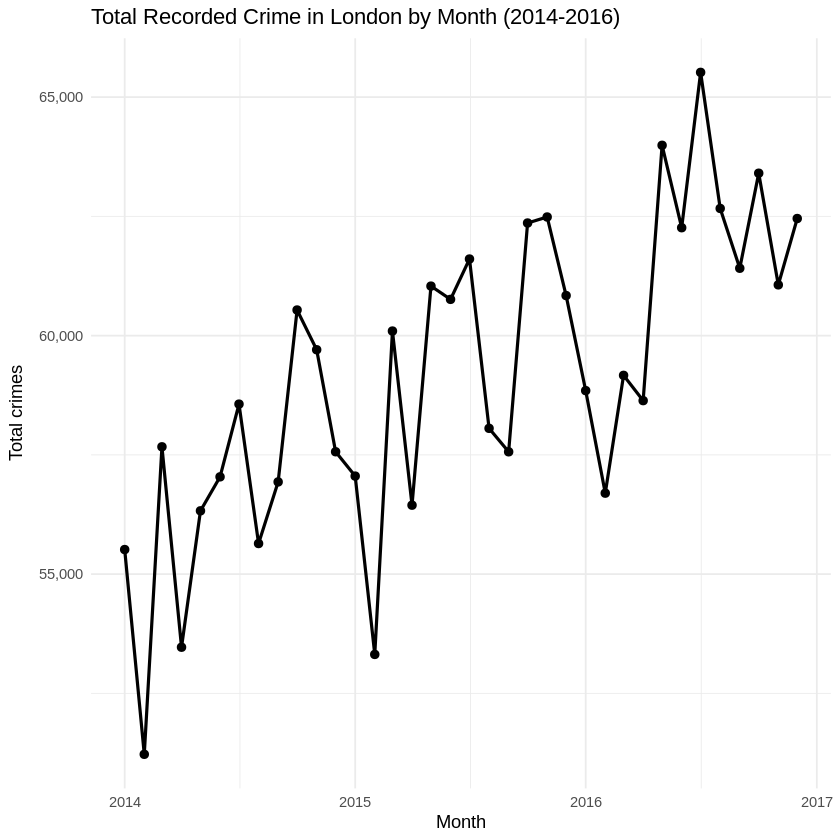

In [68]:
# Create Line Chart to Show Total Crimes in london Through 2014 to 2016
ggplot(monthly_totals, aes(x = crime_month, y = total_crime)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Total Recorded Crime in London by Month (2014-2016)",
    x = "Month",
    y = "Total crimes"
  ) +
  theme_minimal()

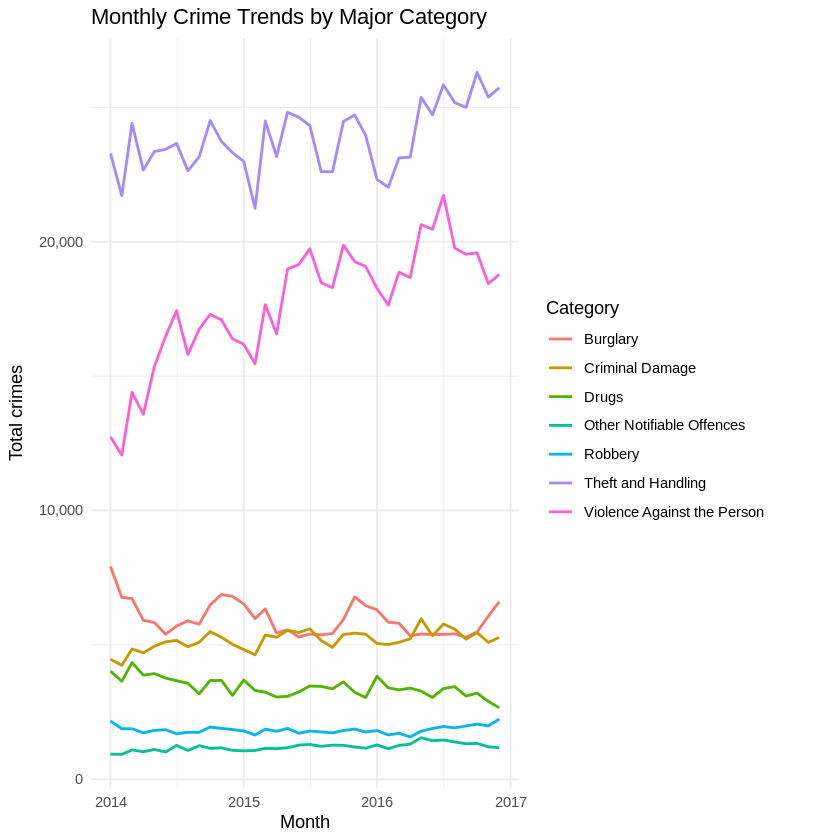

In [69]:
# Line Charts to show total crime categroy over years
ggplot(category_monthly, aes(x = crime_month, y = total_crimes, colour = major_category)) +
  geom_line(linewidth = 0.8) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Monthly Crime Trends by Major Category",
    x = "Month",
    y = "Total crimes",
    colour = "Category"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


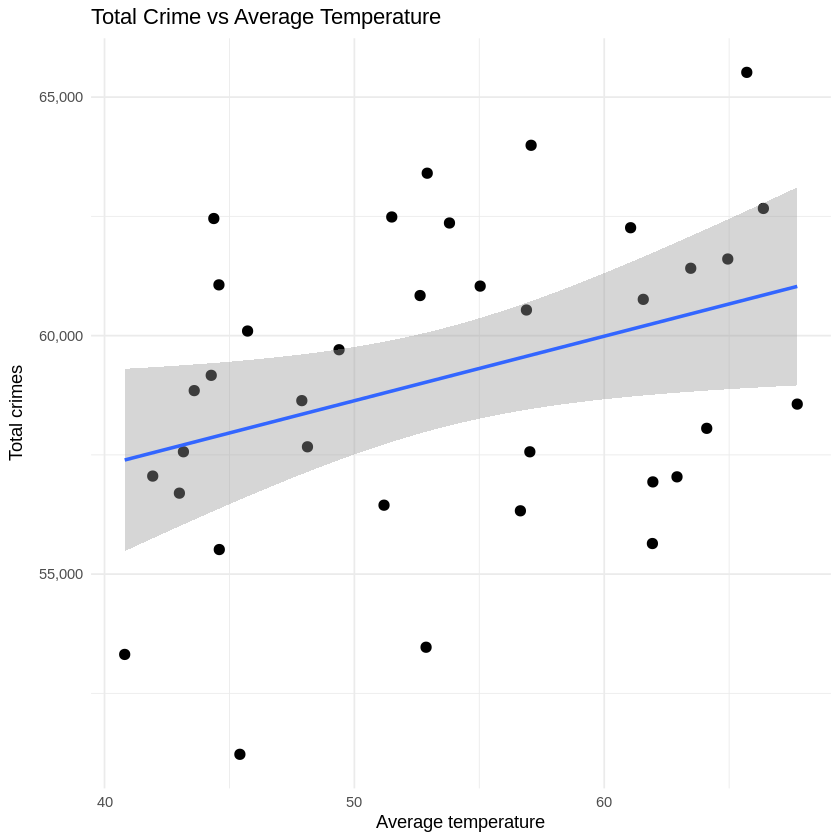

In [70]:
# Line Charts to show total crimes vs average temperature
ggplot(monthly_totals, aes(x = avg_temp, y = total_crime)) +
  geom_point(size = 2.5) +
  geom_smooth(method = "lm", se = TRUE) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Total Crime vs Average Temperature",
    x = "Average temperature",
    y = "Total crimes"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


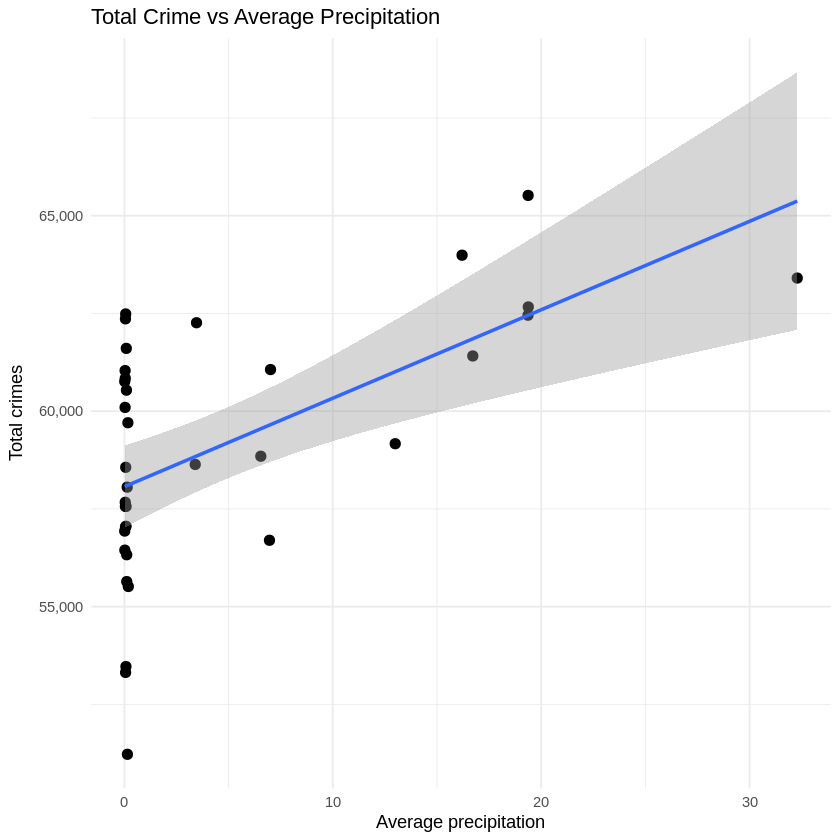

In [71]:
# Line Charts to show total crime vs average rainfall
ggplot(monthly_totals, aes(x = avg_prcp, y = total_crime)) +
  geom_point(size = 2.5) +
  geom_smooth(method = "lm", se = TRUE) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Total Crime vs Average Precipitation",
    x = "Average precipitation",
    y = "Total crimes"
  ) +
  theme_minimal()

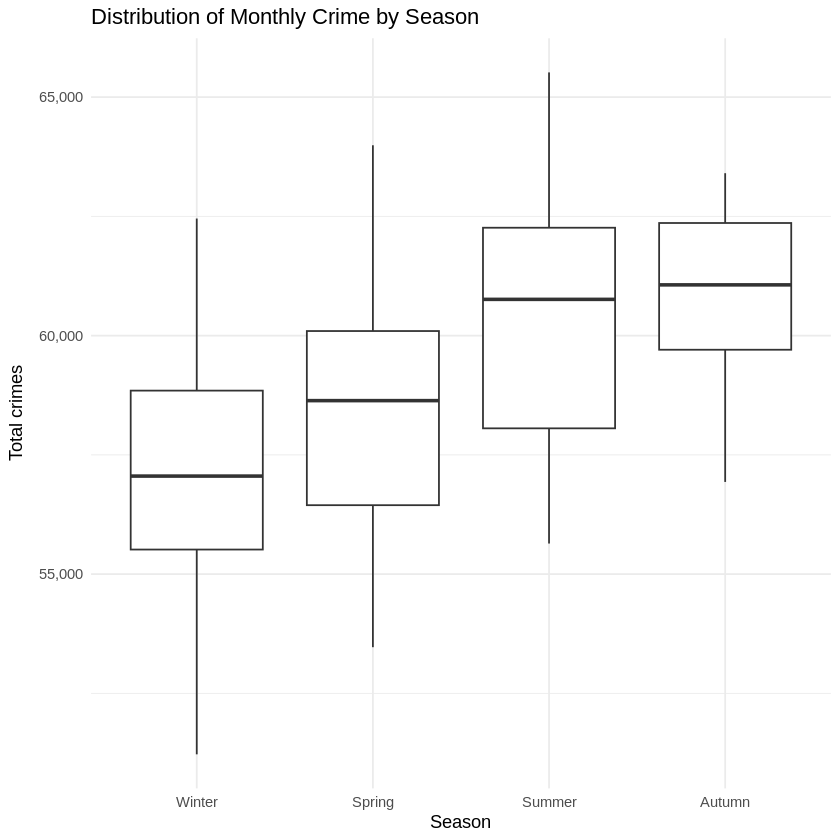

In [72]:
ggplot(monthly_totals, aes(x = season, y = total_crime)) +
  geom_boxplot() +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Distribution of Monthly Crime by Season",
    x = "Season",
    y = "Total crimes"
  ) +
  theme_minimal()

In [73]:
category_summary <- category_monthly %>%
  group_by(major_category) %>%
  summarise(
    mean_crimes = mean(total_crimes, na.rm = TRUE),
    sd_crimes   = sd(total_crimes, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(mean_crimes))

kable(category_summary, digits = 2, caption = "Average monthly crime by major category")



Table: Average monthly crime by major category

|major_category              | mean_crimes| sd_crimes|
|:---------------------------|-----------:|---------:|
|Theft and Handling          |    23834.31|   1228.68|
|Violence Against the Person |    17679.72|   2221.90|
|Burglary                    |     5967.42|    620.36|
|Criminal Damage             |     5175.72|    354.77|
|Drugs                       |     3420.39|    345.32|
|Robbery                     |     1835.03|    137.91|
|Other Notifiable Offences   |     1196.53|    139.20|

## 7. Correlation Analysis
Calculate a correlation matrix for total monthly crime and the main numeric weather variables.

In [74]:
# Overall Correlation Matrix for Monthly Totals
numeric_cor <- monthly_totals %>%
  select(
    total_crime, avg_temp, avg_dewp, avg_slp, avg_visib, avg_wdsp,
    avg_mxpsd, avg_gust, avg_max_temp, avg_min_temp, avg_prcp,
    fog_days
  ) %>%
  cor(use = "complete.obs") %>%
  round(3)

numeric_cor

Warning message in cor(., use = "complete.obs"):
“the standard deviation is zero”


,total_crime,avg_temp,avg_dewp,avg_slp,avg_visib,avg_wdsp,avg_mxpsd,avg_gust,avg_max_temp,avg_min_temp,avg_prcp,fog_days
total_crime,1,1,1,1,1,-1,-1,1,1,1,-1,NA
avg_temp,1,1,1,1,1,-1,-1,1,1,1,-1,NA
avg_dewp,1,1,1,1,1,-1,-1,1,1,1,-1,NA
avg_slp,1,1,1,1,1,-1,-1,1,1,1,-1,NA
avg_visib,1,1,1,1,1,-1,-1,1,1,1,-1,NA
avg_wdsp,-1,-1,-1,-1,-1,1,1,-1,-1,-1,1,NA
avg_mxpsd,-1,-1,-1,-1,-1,1,1,-1,-1,-1,1,NA
avg_gust,1,1,1,1,1,-1,-1,1,1,1,-1,NA
avg_max_temp,1,1,1,1,1,-1,-1,1,1,1,-1,NA
avg_min_temp,1,1,1,1,1,-1,-1,1,1,1,-1,NA


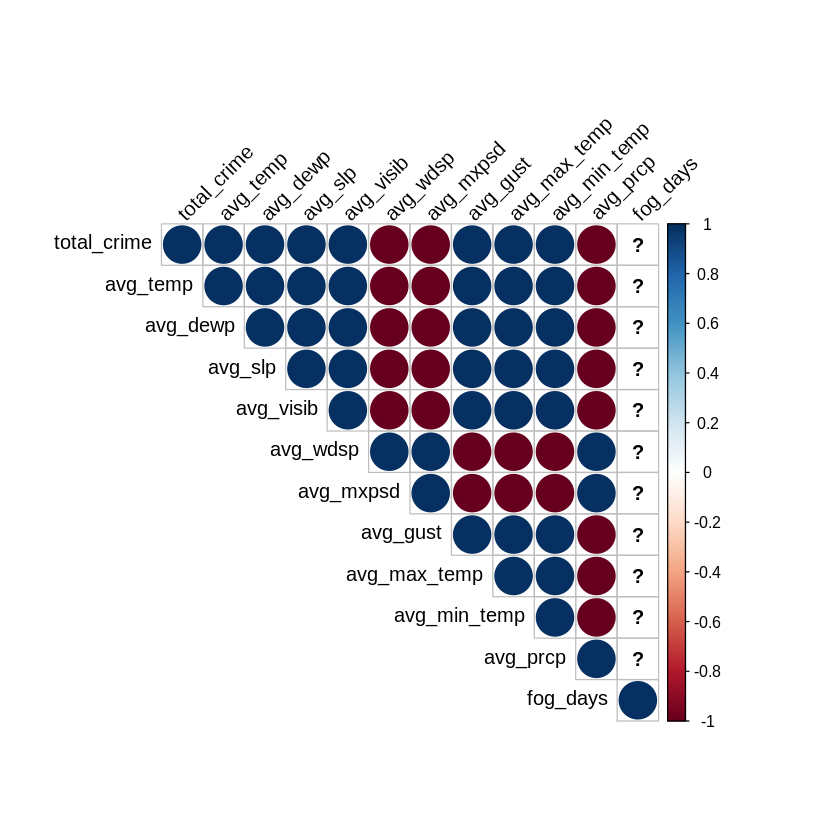

In [75]:
# Overall Correlation Matrix Chart
corrplot(numeric_cor, type = "upper", tl.col = "black", tl.srt = 45)

In [76]:
cor_temp <- cor.test(monthly_totals$total_crime, monthly_totals$avg_temp, method = "pearson")
cor_prcp <- cor.test(monthly_totals$total_crime, monthly_totals$avg_prcp, method = "pearson")
cor_fog  <- cor.test(monthly_totals$total_crime, monthly_totals$fog_days, method = "pearson")

cor_temp
cor_prcp
cor_fog


	Pearson's product-moment correlation

data:  monthly_totals$total_crime and monthly_totals$avg_temp
t = 2.1716, df = 34, p-value = 0.03695
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.02313025 0.60785119
sample estimates:
      cor 
0.3490138 



	Pearson's product-moment correlation

data:  monthly_totals$total_crime and monthly_totals$avg_prcp
t = 4.0232, df = 34, p-value = 0.0003029
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2942865 0.7554905
sample estimates:
      cor 
0.5679142 



	Pearson's product-moment correlation

data:  monthly_totals$total_crime and monthly_totals$fog_days
t = 0.70466, df = 34, p-value = 0.4858
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.2171178  0.4315034
sample estimates:
     cor 
0.119976 


## 8. Category-Level Correlation Analysis
Calculate category-specific correlations to assess whether weather variables and appear to affect some crime categories more strongly than others.

In [77]:
# Correlation of weather variables with crime within each category
category_correlations <- category_monthly %>%
  group_by(major_category) %>%
  summarise(
    cor_temp = cor(total_crimes, avg_temp, use = "complete.obs"),
    cor_prcp = cor(total_crimes, avg_prcp, use = "complete.obs"),
    cor_fog  = cor(total_crimes, fog_days, use = "complete.obs"),
    cor_wdsp = cor(total_crimes, avg_wdsp, use = "complete.obs"),
    .groups = "drop"
  ) %>%
  arrange(desc(cor_temp))

kable(category_correlations, digits = 3,
      caption = "Category-level correlations between crime and weather variables")



Table: Category-level correlations between crime and weather variables

|major_category              | cor_temp| cor_prcp| cor_fog| cor_wdsp|
|:---------------------------|--------:|--------:|-------:|--------:|
|Criminal Damage             |    0.478|    0.405|  -0.094|   -0.199|
|Other Notifiable Offences   |    0.478|    0.563|  -0.100|   -0.347|
|Violence Against the Person |    0.399|    0.502|  -0.109|   -0.219|
|Theft and Handling          |    0.323|    0.589|   0.282|   -0.253|
|Drugs                       |    0.003|   -0.345|  -0.002|    0.089|
|Robbery                     |   -0.076|    0.447|   0.585|   -0.077|
|Burglary                    |   -0.623|   -0.285|   0.400|    0.403|

## 9. Regression Analystics

### 9.1 Multiple Regression
This regression model using several weather variables and season together which tests whether crime can be explained better by a combination of predictors than by simple one-to-one correlations.

In [78]:
multi_model <- lm(
  total_crime ~ avg_temp + avg_prcp + avg_wdsp + avg_visib + fog_days + season,
  data = monthly_totals
)

summary(multi_model)

multi_model_tidy <- tidy(multi_model)
multi_model_glance <- glance(multi_model)

kable(multi_model_tidy, digits = 4,
      caption = "Multiple regression coefficients for monthly total crime")

kable(multi_model_glance, digits = 4,
      caption = "Multiple regression model summary")


Call:
lm(formula = total_crime ~ avg_temp + avg_prcp + avg_wdsp + avg_visib + 
    fog_days + season, data = monthly_totals)

Residuals:
    Min      1Q  Median      3Q     Max 
-6262.2 -1353.8   126.3  1688.6  3547.1 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  52038.768   6671.629   7.800 2.18e-08 ***
avg_temp         4.597    111.533   0.041  0.96743    
avg_prcp       220.608     66.956   3.295  0.00276 ** 
avg_wdsp       427.833    380.844   1.123  0.27116    
avg_visib       -6.962     19.932  -0.349  0.72957    
fog_days        10.846    241.398   0.045  0.96449    
seasonSpring  2220.958   1526.706   1.455  0.15727    
seasonSummer  3847.202   2545.887   1.511  0.14237    
seasonAutumn  3946.159   1840.025   2.145  0.04114 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2569 on 27 degrees of freedom
Multiple R-squared:  0.508,	Adjusted R-squared:  0.3622 
F-statistic: 3.485 on 8 and 27 DF, 



Table: Multiple regression coefficients for monthly total crime

|term         |   estimate| std.error| statistic| p.value|
|:------------|----------:|---------:|---------:|-------:|
|(Intercept)  | 52038.7679| 6671.6293|    7.8000|  0.0000|
|avg_temp     |     4.5972|  111.5325|    0.0412|  0.9674|
|avg_prcp     |   220.6084|   66.9558|    3.2948|  0.0028|
|avg_wdsp     |   427.8333|  380.8439|    1.1234|  0.2712|
|avg_visib    |    -6.9623|   19.9316|   -0.3493|  0.7296|
|fog_days     |    10.8457|  241.3978|    0.0449|  0.9645|
|seasonSpring |  2220.9575| 1526.7057|    1.4547|  0.1573|
|seasonSummer |  3847.2018| 2545.8873|    1.5111|  0.1424|
|seasonAutumn |  3946.1589| 1840.0254|    2.1446|  0.0411|



Table: Multiple regression model summary

| r.squared| adj.r.squared|    sigma| statistic| p.value| df|    logLik|      AIC|      BIC|  deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|---------:|--------:|--------:|---------:|-----------:|----:|
|     0.508|        0.3622| 2569.385|    3.4848|  0.0069|  8| -328.5547| 677.1094| 692.9446| 178246920|          27|   36|

### 9.2 Log Regression
This model using a log-transformed crime outcome, this can reduce the influence of scale and make relationships more stable

In [79]:
log_model <- lm(
  log_total_crime ~ avg_temp + avg_prcp + avg_wdsp + avg_visib + fog_days + season,
  data = monthly_totals
)

summary(log_model)

log_model_tidy <- tidy(log_model)
log_model_glance <- glance(log_model)

kable(log_model_tidy, digits = 4,
      caption = "Log regression coefficients for monthly total crime")

kable(log_model_glance, digits = 4,
      caption = "Log regression model summary")


Call:
lm(formula = log_total_crime ~ avg_temp + avg_prcp + avg_wdsp + 
    avg_visib + fog_days + season, data = monthly_totals)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.112960 -0.022738  0.002955  0.026569  0.062471 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.087e+01  1.157e-01  93.908  < 2e-16 ***
avg_temp      4.175e-05  1.935e-03   0.022  0.98294    
avg_prcp      3.684e-03  1.162e-03   3.172  0.00375 ** 
avg_wdsp      7.054e-03  6.607e-03   1.068  0.29508    
avg_visib    -1.056e-04  3.458e-04  -0.305  0.76239    
fog_days      2.232e-04  4.188e-03   0.053  0.95788    
seasonSpring  3.835e-02  2.648e-02   1.448  0.15916    
seasonSummer  6.612e-02  4.416e-02   1.497  0.14593    
seasonAutumn  6.817e-02  3.192e-02   2.136  0.04192 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.04457 on 27 degrees of freedom
Multiple R-squared:  0.4943,	Adjusted R-squared:  0.344



Table: Log regression coefficients for monthly total crime

|term         | estimate| std.error| statistic| p.value|
|:------------|--------:|---------:|---------:|-------:|
|(Intercept)  |  10.8686|    0.1157|   93.9084|  0.0000|
|avg_temp     |   0.0000|    0.0019|    0.0216|  0.9829|
|avg_prcp     |   0.0037|    0.0012|    3.1720|  0.0038|
|avg_wdsp     |   0.0071|    0.0066|    1.0678|  0.2951|
|avg_visib    |  -0.0001|    0.0003|   -0.3054|  0.7624|
|fog_days     |   0.0002|    0.0042|    0.0533|  0.9579|
|seasonSpring |   0.0383|    0.0265|    1.4479|  0.1592|
|seasonSummer |   0.0661|    0.0442|    1.4972|  0.1459|
|seasonAutumn |   0.0682|    0.0319|    2.1357|  0.0419|



Table: Log regression model summary

| r.squared| adj.r.squared|  sigma| statistic| p.value| df|  logLik|       AIC|      BIC| deviance| df.residual| nobs|
|---------:|-------------:|------:|---------:|-------:|--:|-------:|---------:|--------:|--------:|-----------:|----:|
|    0.4943|        0.3444| 0.0446|    3.2985|  0.0093|  8| 66.0797| -112.1593| -96.3242|   0.0536|          27|   36|

## 10. Model Comparison
Compare the standard and log-transformed models using fit statistics.

In [80]:
model_comparison <- tibble(
  model = c("Multiple Regression", "Log Regression"),
  r_squared = c(glance(multi_model)$r.squared, glance(log_model)$r.squared),
  adj_r_squared = c(glance(multi_model)$adj.r.squared, glance(log_model)$adj.r.squared),
  aic = c(AIC(multi_model), AIC(log_model)),
  bic = c(BIC(multi_model), BIC(log_model))
)

kable(model_comparison, digits = 4,
      caption = "Comparison of monthly crime regression models")



Table: Comparison of monthly crime regression models

|model               | r_squared| adj_r_squared|       aic|      bic|
|:-------------------|---------:|-------------:|---------:|--------:|
|Multiple Regression |    0.5080|        0.3622|  677.1094| 692.9446|
|Log Regression      |    0.4943|        0.3444| -112.1593| -96.3242|

## 11. Regression Diagnostics
Examine residual behaviour to assess whether the regression model assumptions appear reasonable.

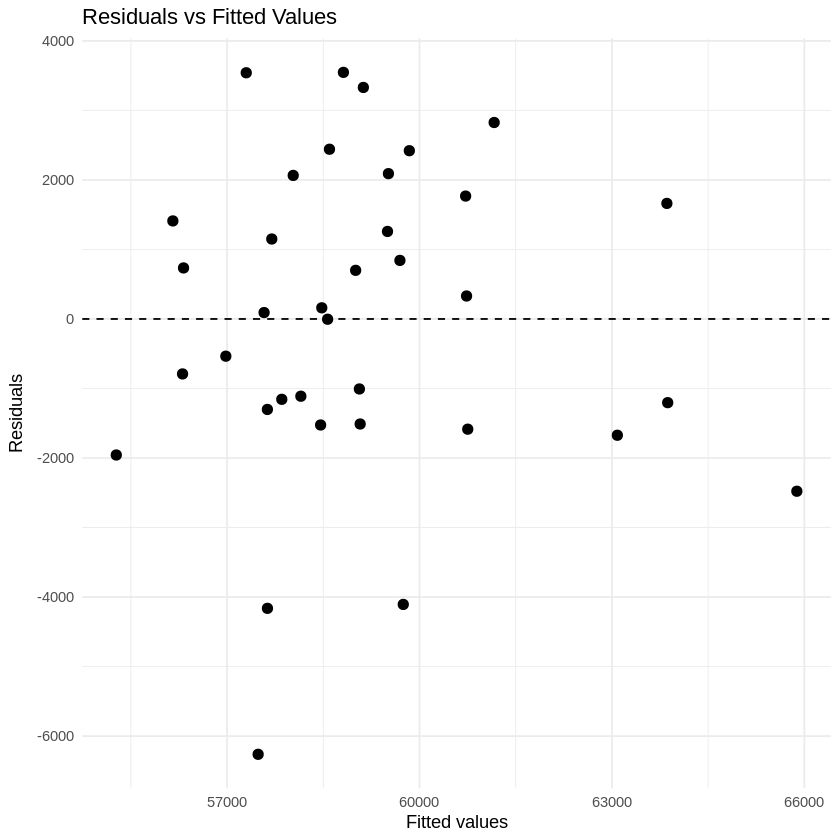

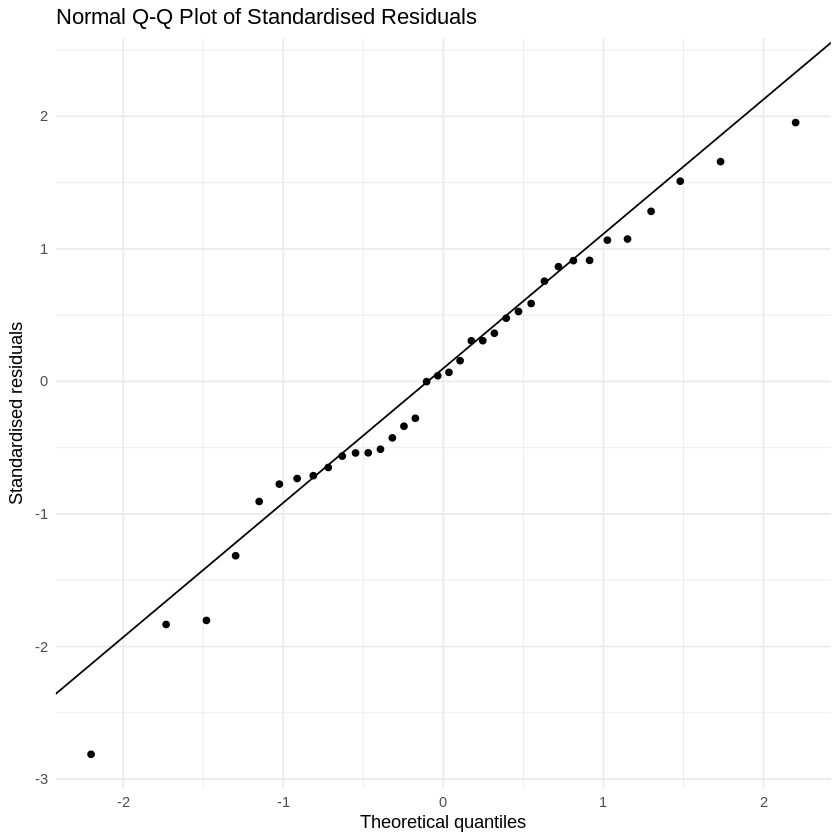

In [81]:
aug_multi <- augment(multi_model)

# Residuals vs fitted
ggplot(aug_multi, aes(x = .fitted, y = .resid)) +
  geom_point(size = 2.5) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "Residuals vs Fitted Values",
    x = "Fitted values",
    y = "Residuals"
  ) +
  theme_minimal()

# Normal Q-Q plot
ggplot(aug_multi, aes(sample = .std.resid)) +
  stat_qq() +
  stat_qq_line() +
  labs(
    title = "Normal Q-Q Plot of Standardised Residuals",
    x = "Theoretical quantiles",
    y = "Standardised residuals"
  ) +
  theme_minimal()

## 12. Seasonal and Quarterly Patterns
Summarise whether crime and selected weather variables differ by season and quarter.

In [82]:
season_summary <- monthly_totals %>%
  group_by(season) %>%
  summarise(
    mean_crime = mean(total_crime, na.rm = TRUE),
    sd_crime   = sd(total_crime, na.rm = TRUE),
    mean_temp  = mean(avg_temp, na.rm = TRUE),
    mean_prcp  = mean(avg_prcp, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(mean_crime))

quarter_summary <- monthly_totals %>%
  group_by(quarter) %>%
  summarise(
    mean_crime = mean(total_crime, na.rm = TRUE),
    sd_crime   = sd(total_crime, na.rm = TRUE),
    .groups = "drop"
  )

kable(season_summary, digits = 2, caption = "Seasonal summary of crime and weather")
kable(quarter_summary, digits = 2, caption = "Quarterly summary of crime")



Table: Seasonal summary of crime and weather

|season | mean_crime| sd_crime| mean_temp| mean_prcp|
|:------|----------:|--------:|---------:|---------:|
|Autumn |   60607.44|  2204.40|     54.61|      6.28|
|Summer |   60234.78|  3141.54|     64.03|      4.74|
|Spring |   58537.33|  3052.59|     50.98|      3.66|
|Winter |   57056.89|  3490.37|     44.39|      3.71|



Table: Quarterly summary of crime

|quarter | mean_crime| sd_crime|
|:-------|----------:|--------:|
|1       |   56620.44|  2874.47|
|2       |   58885.00|  3371.52|
|3       |   59773.44|  3198.84|
|4       |   61157.56|  1784.10|

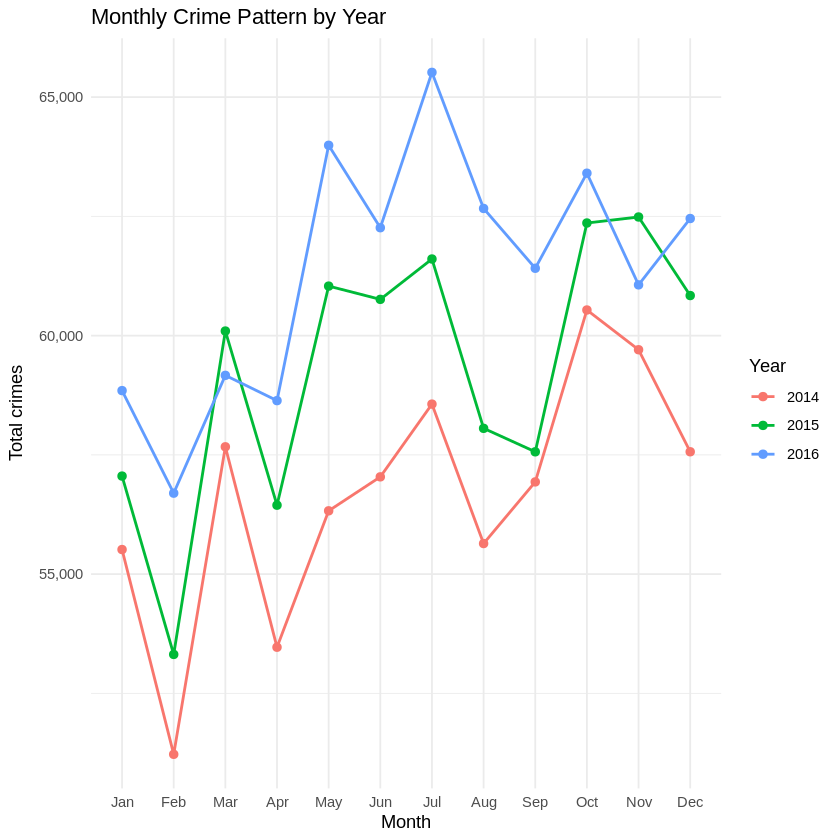

In [83]:
# Chart Displau
ggplot(monthly_totals, aes(x = month_factor, y = total_crime, group = year, colour = factor(year))) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Monthly Crime Pattern by Year",
    x = "Month",
    y = "Total crimes",
    colour = "Year"
  ) +
  theme_minimal()

## 13. Category-Level Regression Analysis
Fit separate regression models by crime category to examine whether the explanatory power of weather variables differs across offence types.

In [84]:
category_models <- category_monthly %>%
  group_by(major_category) %>%
  nest() %>%
  mutate(
    model = map(data, ~ lm(total_crimes ~ avg_temp + avg_prcp + avg_wdsp + fog_days, data = .x)),
    tidied = map(model, tidy),
    glanced = map(model, glance)
  )

category_model_results <- category_models %>%
  select(major_category, glanced) %>%
  unnest(glanced) %>%
  select(major_category, r.squared, adj.r.squared, sigma, statistic, p.value) %>%
  arrange(desc(adj.r.squared))

kable(category_model_results, digits = 4,
      caption = "Regression model performance by crime category")



Table: Regression model performance by crime category

|major_category              | r.squared| adj.r.squared|     sigma| statistic| p.value|
|:---------------------------|---------:|-------------:|---------:|---------:|-------:|
|Burglary                    |    0.7156|        0.6789|  351.5323|   19.5002|  0.0000|
|Other Notifiable Offences   |    0.5893|        0.5363|   94.7879|   11.1217|  0.0000|
|Robbery                     |    0.4662|        0.3974|  107.0610|    6.7692|  0.0005|
|Theft and Handling          |    0.4590|        0.3892|  960.2573|    6.5756|  0.0006|
|Violence Against the Person |    0.4408|        0.3687| 1765.4379|    6.1097|  0.0010|
|Criminal Damage             |    0.3739|        0.2931|  298.2746|    4.6285|  0.0048|
|Drugs                       |    0.1751|        0.0686|  333.2630|    1.6447|  0.1881|

## 14. Ranked Relationships
Rank selected weather variables by the absolute strength of their correlation with total monthly crime.

In [85]:
# 14. Ranked Relationships

overall_relationships <- tibble(
  variable = c("avg_temp", "avg_prcp", "fog_days", "avg_wdsp", "avg_visib"),
  correlation = c(
    cor(monthly_totals$total_crime, monthly_totals$avg_temp, use = "complete.obs"),
    cor(monthly_totals$total_crime, monthly_totals$avg_prcp, use = "complete.obs"),
    cor(monthly_totals$total_crime, monthly_totals$fog_days, use = "complete.obs"),
    cor(monthly_totals$total_crime, monthly_totals$avg_wdsp, use = "complete.obs"),
    cor(monthly_totals$total_crime, monthly_totals$avg_visib, use = "complete.obs")
  )
) %>%
  mutate(abs_correlation = abs(correlation)) %>%
  arrange(desc(abs_correlation))

kable(overall_relationships, digits = 3,
      caption = "Ranked strength of correlations with total monthly crime")



Table: Ranked strength of correlations with total monthly crime

|variable  | correlation| abs_correlation|
|:---------|-----------:|---------------:|
|avg_prcp  |       0.568|           0.568|
|avg_temp  |       0.349|           0.349|
|avg_wdsp  |      -0.201|           0.201|
|avg_visib |      -0.138|           0.138|
|fog_days  |       0.120|           0.120|

## 15. Save Analysis Results
Export the processed datasets so that they can be reused in the regression and TensorFlow notebooks for predictive modelling.

In [86]:
write_csv(category_monthly, "category_monthly.csv")
write_csv(monthly_totals, "monthly_totals.csv")